*Deep Learning Project 1* : **CIFAR 10 Dataset Image Classification using Neural Networks**

In [ ]:
from datasets import load_dataset

ds = load_dataset("mteb/cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [ ]:
ds['train'].column_names

['img', 'label']

In [ ]:
train_subset = ds['train'].select_columns(["img","label"])

In [ ]:
train_subset['img']

Column([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x786B7688C080>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x786B7684FF20>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x786B7D19FF80>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x786B7688F050>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x786B7688F8C0>])

In [ ]:
labels = train_subset['label']

In [ ]:
ds['train'].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [ ]:
ds['train'].features['label'].dtype

'int64'

In [ ]:
classes = ds['train'].features['label'].names

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [ ]:
def show_images_pil(img_list, n_rows=2, n_cols=5, titles=None):
    plt.figure(figsize=(2*n_cols, 2*n_rows))
    for i, img in enumerate(img_list[:n_rows * n_cols]):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)          # img is a PIL.PngImageFile
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i])
    plt.tight_layout()
    plt.show()


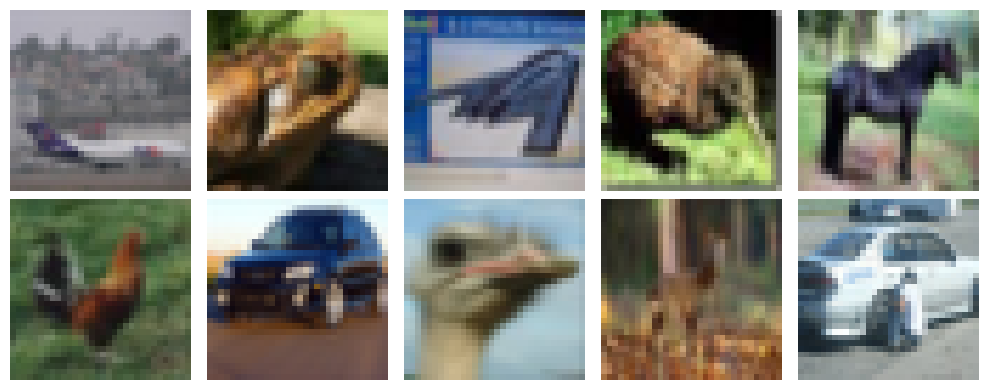

airplane -- frog -- airplane -- bird -- horse
bird -- automobile -- bird -- deer -- automobile


In [ ]:
# imgs is a list of PIL.PngImagePlugin.PngImageFile
show_images_pil(train_subset['img'], n_rows=2, n_cols=5)
print(" -- ".join(f"{classes[labels[j]]}" for j in range(5)))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(5,10)))


In [ ]:
for i in range(10):
  print(classes[i])

airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck


In [ ]:
from collections import Counter

label_counts = Counter(labels)
print(label_counts)


Counter({0: 5000, 6: 5000, 2: 5000, 7: 5000, 1: 5000, 4: 5000, 5: 5000, 3: 5000, 8: 5000, 9: 5000})


In [ ]:
len(train_subset['label'])

50000

CIFAR Dataset is perfectly balanced dataset with equal number of images per class

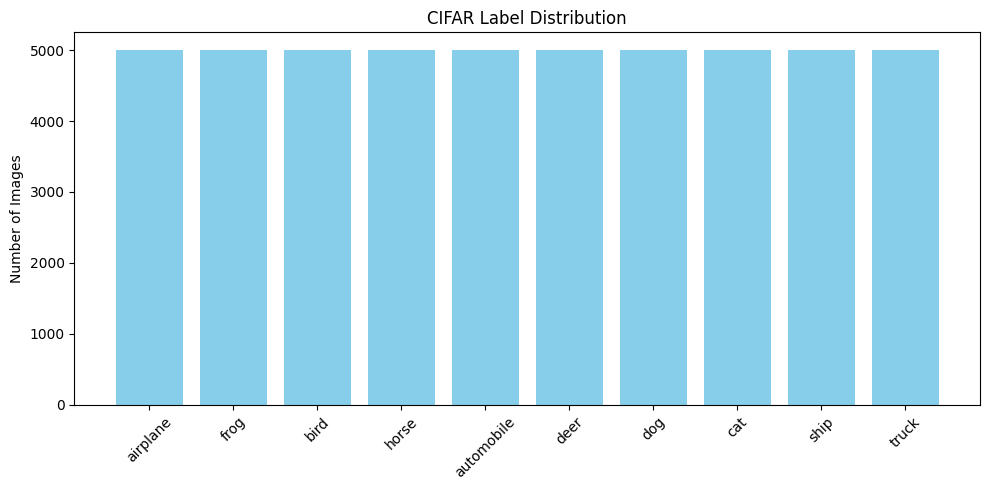

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
x = list(label_counts.keys())
y = [label_counts[i] for i in x]
names = [classes[i] for i in x]

plt.figure(figsize=(10, 5))
plt.bar(names, y, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("CIFAR Label Distribution")
plt.tight_layout()
plt.show()


Show Images with label == 0 (Airplane)

In [ ]:
airplane_subset = train_subset.filter(lambda x: x["label"] in [0])


Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

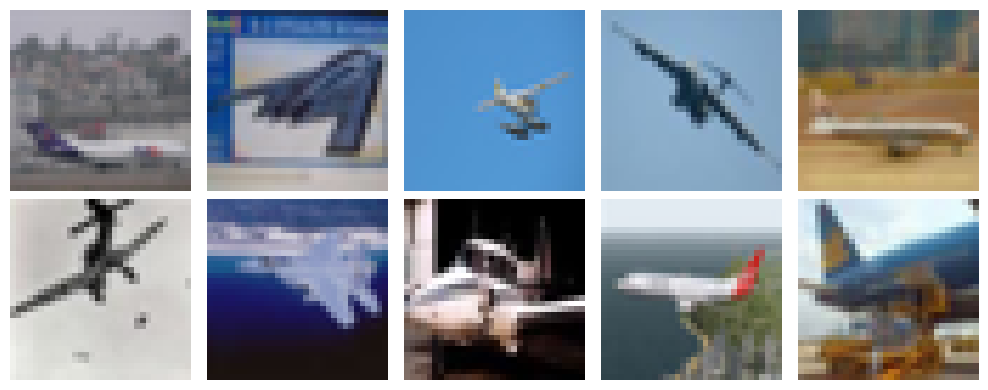

In [ ]:
show_images_pil(airplane_subset['img'], n_rows=2, n_cols=5)

In [ ]:
ref_img = airplane_subset['img'][0]   # PIL.PngImageFile

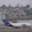

In [ ]:
ref_img

In [ ]:
import numpy as np

ref_arr = np.array(ref_img)

matches = []
for img in airplane_subset['img']:
    if np.array_equal(np.array(img), ref_arr):

        matches.append(img)
print("Number of identical images:", len(matches))




Number of identical images: 1


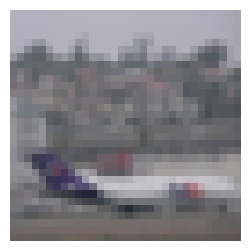

In [ ]:
# visualize all matches
plt.figure(figsize=(12, 3))

for i, img in enumerate(matches):
    plt.subplot(1, len(matches), i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


**Leveraging Pytorch for train dataset to get baseline accuracy**

In [ ]:
import torch
import time
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

In [ ]:
# Set the random seed
torch.manual_seed(52)

In [ ]:
# Load full CIFAR dataset and nomalize the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 80.0MB/s]


In [ ]:
# Create a smaller dataset by selecting a subset (e.g., 1000 samples) since training the full dataset is slow
small_dataset_size = 1000  # Specify the size of the smaller dataset
small_dataset = Subset(full_dataset, list(range(small_dataset_size)))
small_dataset_test = Subset(test_full_dataset, list(range(small_dataset_size)))

In [ ]:
# Create a DataLoader with smaller batch size for the subset
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

In [ ]:
test_loader = DataLoader(small_dataset_test,batch_size=32, shuffle=True)

In [ ]:
len(train_loader)

32

In [ ]:
len(test_loader)

32

In [ ]:
# Define model parameters for CIFAR10
n_x = 32 * 32 * 3  # Input size: 32x32 grayscale images flattened to a 1D array
n_h1 = 128  # Number of neurons in the first hidden layer
n_h2 = 64  # Number of neurons in the second hidden layer
n_output = 10  # 10 output classes (for MNIST)
learning_rate = 0.4
epochs = 250  # Reduce the number of iterations

In [ ]:
# Softmax function
def softmax(Z):
    E = torch.exp(Z)
    EXP = torch.sum(E, dim=0, keepdim=True)
    return E/EXP



In [ ]:
# Cross-entropy loss
def cross_entropy_loss(A, y):
    eps = 1e-12
    return torch.sum(-y * torch.log(A + eps))/y.shape[1]


In [ ]:
# Neural network for CIFAR10 Dataset for Image classification
def pytorch_3_layer_network(X, y, n_x, n_h1, n_h2, n_output, learning_rate, epochs):
    # Initialize weights and biases using torch.nn.Parameter(), so Pytorch knows they are parameters
    W1 = torch.nn.Parameter(torch.randn(n_h1, n_x, dtype=torch.float32) * 0.01) # Use torch.nn.Parameter() and torch.randn(dimesion1, dimesion2, dtype=torch.float32) * 0.01
    b1 = torch.nn.Parameter(torch.zeros((n_h1, 1), dtype=torch.float32)) # Use torch.nn.Parameter() and torch.zeros((dimesion1, dimesion2), dtype=torch.float32)

    W2 = torch.nn.Parameter(torch.randn(n_h2, n_h1, dtype=torch.float32) * 0.01) # Use torch.nn.Parameter() and torch.randn(dimesion1, dimesion2, dtype=torch.float32) * 0.01
    b2 = torch.nn.Parameter(torch.zeros((n_h2, 1), dtype=torch.float32)) # Use torch.nn.Parameter() and torch.zeros((dimesion1, dimesion2), dtype=torch.float32)

    W3 = torch.nn.Parameter(torch.randn(n_output, n_h2, dtype=torch.float32) * 0.01) # Use torch.nn.Parameter() and torch.randn(dimesion1, dimesion2, dtype=torch.float32) * 0.01
    b3 = torch.nn.Parameter(torch.zeros((n_output, 1), dtype=torch.float32)) # Use torch.nn.Parameter() and torch.zeros((dimesion1, dimesion2), dtype=torch.float32)

    cost_values = []

    for epoch in range(epochs):
        print(f"Epoch: {epoch}")
        for data in train_loader:
            inputs, labels = data
            X = inputs.view(-1, 32*32*3).T # Flatten the images and transpose, you can use inputs.view(-1, dimension).T
            y = labels
            y_onehot = torch.nn.functional.one_hot(y, num_classes=10).T.float()

            # Forward propagation
            Z1 = torch.mm(W1, X) +b1  # First hidden layer pre-activation, use torch.mm()
            A1 = torch.sigmoid(Z1)  # First hidden layer activation, use torch.sigmoid()

            Z2 = torch.mm(W2,A1) +b2  # Second hidden layer pre-activation, use torch.mm()
            A2 = torch.sigmoid(Z2)  # Second hidden layer activation, use torch.sigmoid()

            Z3 = torch.mm(W3,A2) +b3  # Output layer pre-activation (logits), use torch.mm()

            # Softmax activation for multi-class classification
            A3 = softmax(Z3)  # Apply softmax to get class probabilities

            # Compute the cross-entropy loss
            J = cross_entropy_loss(A3, y_onehot)

            # Backward propagation (calculate gradients)
            J.backward() # Only one line

            # Update weights and biases using gradient descent
            with torch.no_grad():
              W1 -= learning_rate * W1.grad # W1
              b1 -= learning_rate * b1.grad # b1
              W2 -= learning_rate * W2.grad # W2
              b2 -= learning_rate * b2.grad # b2
              W3 -= learning_rate * W3.grad # W3
              b3 -= learning_rate * b3.grad # b3

            # Zero the gradients after updating, use XXX.grad.zero_()
              W1.grad.zero_() # Zero the gradients of W1
              b1.grad.zero_() # Zero the gradients of b1
              W2.grad.zero_() # Zero the gradients of W2
              b2.grad.zero_() # Zero the gradients of b2
              W3.grad.zero_() # Zero the gradients of W3
              b3.grad.zero_() # Zero the gradients of b3

            cost_values.append(J.item())

    return cost_values, W1, b1, W2, b2, W3, b3

In [ ]:
### Timing and execution ###
start_time = time.time()
cost_values, W1_t, b1_t, W2_t, b2_t, W3_t, b3_t = pytorch_3_layer_network(None, None, n_x, n_h1, n_h2, n_output, learning_rate, epochs)
total_time = time.time() - start_time

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29
Epoch: 30
Epoch: 31
Epoch: 32
Epoch: 33
Epoch: 34
Epoch: 35
Epoch: 36
Epoch: 37
Epoch: 38
Epoch: 39
Epoch: 40
Epoch: 41
Epoch: 42
Epoch: 43
Epoch: 44
Epoch: 45
Epoch: 46
Epoch: 47
Epoch: 48
Epoch: 49
Epoch: 50
Epoch: 51
Epoch: 52
Epoch: 53
Epoch: 54
Epoch: 55
Epoch: 56
Epoch: 57
Epoch: 58
Epoch: 59
Epoch: 60
Epoch: 61
Epoch: 62
Epoch: 63
Epoch: 64
Epoch: 65
Epoch: 66
Epoch: 67
Epoch: 68
Epoch: 69
Epoch: 70
Epoch: 71
Epoch: 72
Epoch: 73
Epoch: 74
Epoch: 75
Epoch: 76
Epoch: 77
Epoch: 78
Epoch: 79
Epoch: 80
Epoch: 81
Epoch: 82
Epoch: 83
Epoch: 84
Epoch: 85
Epoch: 86
Epoch: 87
Epoch: 88
Epoch: 89
Epoch: 90
Epoch: 91
Epoch: 92
Epoch: 93
Epoch: 94
Epoch: 95
Epoch: 96
Epoch: 97
Epoch: 98
Epoch: 99
Epoch: 100

In [ ]:
W1_t

torch.Size([128, 3072])

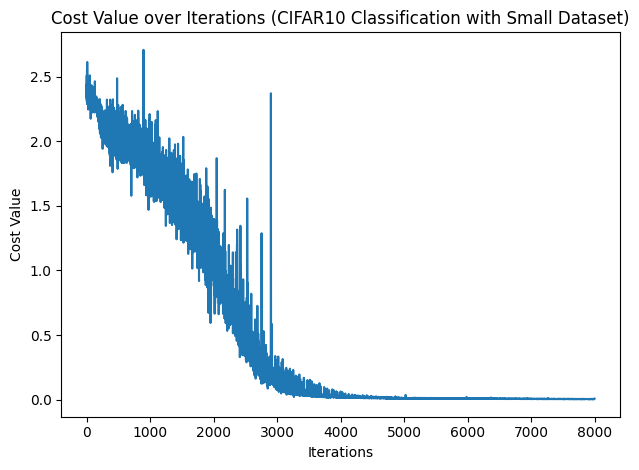

In [ ]:
# Plotting the cost value over iterations
plt.plot(range(len(cost_values)), cost_values)
plt.xlabel('Iterations')
plt.ylabel('Cost Value')
plt.title('Cost Value over Iterations (CIFAR10 Classification with Small Dataset)')
plt.tight_layout()
plt.savefig("cost_CIFAR10_small_dataset.png")

In [ ]:
print(f"Time: {total_time:.6f} seconds")
print(f"Final cost value: {cost_values[-1]:.6f}")

Time: 89.058288 seconds
Final cost value: 0.006524


**Validate against test data**

In [ ]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = W1 @ X + b1
    A1 = torch.sigmoid(Z1)

    Z2 = W2 @ A1 + b2
    A2 = torch.sigmoid(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)   # your softmax function

    return A3


In [ ]:
def evaluate_model(W1, b1, W2, b2, W3, b3):
    correct = 0
    total = 0

    for images, labels in test_loader:
        # Flatten and transpose: (batch, 3,32,32) → (3072, batch)
        X = images.view(-1, 32*32*3).T

        # Forward pass
        probs = forward_pass(X, W1, b1, W2, b2, W3, b3)

        # Predicted class for each sample
        y_pred = probs.argmax(dim=0)   # dim=0 because shape = (10, batch)

        correct += (y_pred == labels).sum().item()
        total += labels.size(0)

    print(correct)
    print(total)

    accuracy = correct / total
    return accuracy


In [ ]:
test_acc = evaluate_model(W1_t, b1_t, W2_t, b2_t, W3_t, b3_t)
print("Test Accuracy:", test_acc)

276
1000
Test Accuracy: 0.276


Test acurracy with learning rate of 0.8 and 100 epochs: 28%

Try with adding regularizer and relu functions